# Sketch → constrain → solve → solid

jaxCAD models CAD workflows with **two trees sharing one set of parameters**:

- the **construction tree** — sketch planes and 2D profiles whose vertices are
  free `Vector2` parameters. This is what you edit and constrain.
- the **SDF tree** — solids *generated* from profiles (`extrude`, `revolve`).
  Generation preserves parameter references, so solving constraints on the
  sketch, or running gradients through the solid, act on the same values.

The construction tree is never part of the SDF render; it is projected through
the same camera and drawn as a wireframe overlay.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcad import extract_parameters, functionalize
from jaxcad.constraints import DistanceConstraint, FixedConstraint
from jaxcad.constraints.solve import project_to_manifold, solve_constraints
from jaxcad.construction import PolygonProfile, SketchPlane, extrude, revolve
from jaxcad.render import (
    Camera,
    Material,
    RenderSettings,
    Scene,
    draw_plane,
    draw_profile,
    render_scene,
)
from jaxcad.sdf import volume
from jaxcad.sdf.primitives import Plane

## 1. Sketch a profile

A `PolygonProfile` lives on a `SketchPlane`. Raw vertex arrays become **free**
`Vector2` parameters (2 DOF each) — editable until constrained, like a CAD
sketch.

In [2]:
profile = PolygonProfile(
    [[0.1, -0.1], [1.9, 0.2], [1.0, 1.5]],
    plane=SketchPlane(origin=[0.0, -0.5, 0.0], normal=[0.0, 0.0, 1.0]),
    name="tri",
)
profile.vertices

[Vector2(value=Array([ 0.1, -0.1], dtype=float32), free=True, name='tri_v0', bounds=None),
 Vector2(value=Array([1.9, 0.2], dtype=float32), free=True, name='tri_v1', bounds=None),
 Vector2(value=Array([1. , 1.5], dtype=float32), free=True, name='tri_v2', bounds=None)]

## 2. Constrain and solve

Anchor two vertices and pin the apex with two distance constraints: 6 DOF,
6 constraint equations — exactly constrained. `solve_constraints` walks the
construction tree, finds the constraints registered on its parameters, and
solves with Levenberg–Marquardt. The solution lands on an equilateral triangle.

In [3]:
v0, v1, v2 = profile.vertices
FixedConstraint(v0, [0.0, 0.0])
FixedConstraint(v1, [2.0, 0.0])
DistanceConstraint(v0, v2, 2.0)
DistanceConstraint(v1, v2, 2.0)

solved = solve_constraints(profile)
for name, value in solved.items():
    print(f"{name}: {value}")

tri_v0: [-9.3816510e-11 -1.6287771e-10]
tri_v1: [2.000000e+00 1.165148e-10]
tri_v2: [1.        1.7320509]


## 3. Generate a solid and render with the sketch overlay

`extrude` produces an SDF primitive that **shares** the profile's vertex
parameters and places it on the sketch plane. We render the solid with the
forward renderer, then draw the construction tree on top: dashed plane
outline, profile edges, vertex handles.

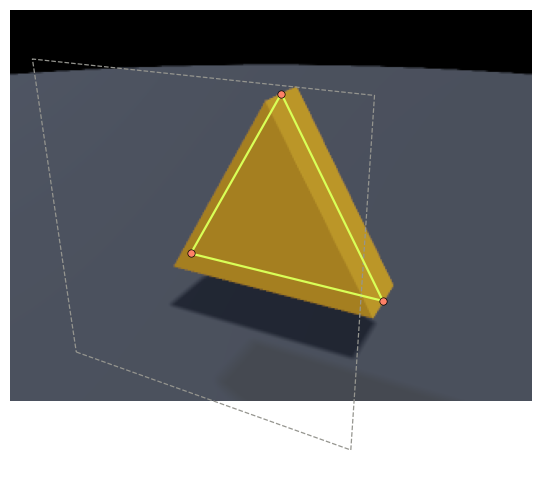

In [4]:
solid = extrude(profile, depth=0.6, material=Material(color=[0.9, 0.55, 0.08], roughness=0.35))

scene = Scene(
    solid | Plane(-1.2, material=Material(color=[0.12, 0.14, 0.18], roughness=0.8)),
    camera=Camera(position=(3.2, 2.4, 4.6), target=(0.9, 0.2, 0.0), fov=0.42),
    light_directions=((0.4, 1.0, 0.5), (-0.5, 0.4, -0.3)),
    light_colors=((1.3, 1.2, 1.05), (0.25, 0.3, 0.45)),
)
settings = RenderSettings.balanced((240, 320))

# write solved values back into the shared params: the render below uses
# the constraint-solved sketch
for v in profile.vertices:
    v.value = solved[v.name]

image = render_scene(scene, settings)
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(image)
draw_plane(ax, profile.plane, scene.camera, settings.resolution, extent=1.8)
draw_profile(ax, profile, scene.camera, settings.resolution)
ax.axis("off");

## 4. Revolve

The same profile machinery drives solids of revolution. Profile coordinates
are (radial, height); the profile revolves around the sketch plane's local
Y axis.

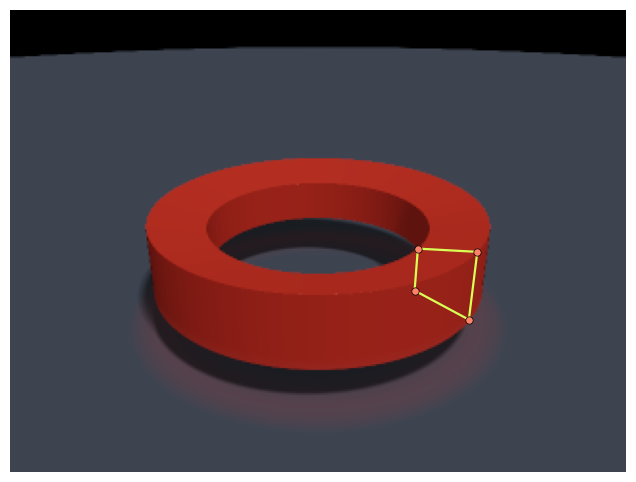

In [5]:
washer = PolygonProfile([[0.9, -0.18], [1.35, -0.28], [1.35, 0.28], [0.9, 0.18]], name="washer")
ring = revolve(washer, material=Material(color=[0.78, 0.08, 0.05], roughness=0.4))

ring_scene = Scene(
    ring | Plane(-0.6, material=Material(color=[0.12, 0.14, 0.18], roughness=0.8)),
    camera=Camera(position=(2.6, 2.2, 3.8), target=(0.0, 0.0, 0.0), fov=0.5),
)
image = render_scene(ring_scene, settings)
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(image)
draw_profile(ax, washer, ring_scene.camera, settings.resolution)
ax.axis("off");

## 5. Constrained optimization through the generated solid

The full differentiable-CAD loop: a quad sketch with one anchor and one pinned
edge length (3 constraint equations on 8 DOF), extruded into a solid. We
optimize the remaining sketch DOF so the solid's volume hits a target, and
project back onto the constraint manifold after every gradient step.

final volume: 6.278 (target 6.0)
edge length: 2.0000 (pinned 2.0)


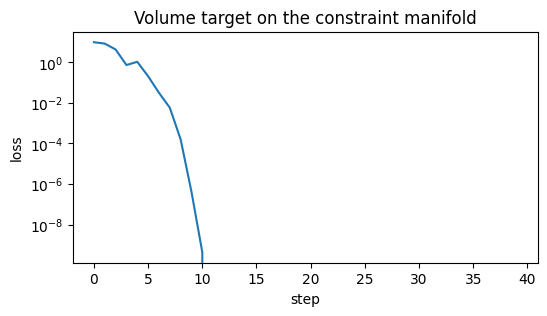

In [6]:
quad = PolygonProfile([[0.0, 0.0], [2.0, 0.0], [2.0, 1.0], [0.0, 1.0]], name="quad")
q0, q1, q2, q3 = quad.vertices
FixedConstraint(q0, [0.0, 0.0])
DistanceConstraint(q0, q1, 2.0)

quad_solid = extrude(quad, depth=1.5, material=Material(color=[0.05, 0.2, 0.7], roughness=0.3))
free, fixed, meta = extract_parameters(quad_solid)
fn = functionalize(quad_solid)
target = 6.0


def loss(params):
    vol = volume(fn(params, fixed), bounds=(-1, -1, -1), size=(4, 4, 2), resolution=32)
    return (vol - target) ** 2


params = dict(free)
history = []
for _ in range(40):
    value, grads = jax.value_and_grad(loss)(params)
    history.append(float(value))
    params = {k: v - 0.05 * grads[k] for k, v in params.items()}
    params = project_to_manifold(params, meta, steps=2)

vol = volume(fn(params, fixed), bounds=(-1, -1, -1), size=(4, 4, 2), resolution=64)
print(f"final volume: {float(vol):.3f} (target {target})")
print(
    f"edge length: {float(jnp.linalg.norm(params['quad_v1'] - params['quad_v0'])):.4f} (pinned 2.0)"
)

plt.figure(figsize=(6, 3))
plt.semilogy(history)
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Volume target on the constraint manifold");

## 6. Optimized solid with its sketch

Write the optimized values back into the shared parameters and render — the
sketch overlay shows the final constrained profile driving the solid.

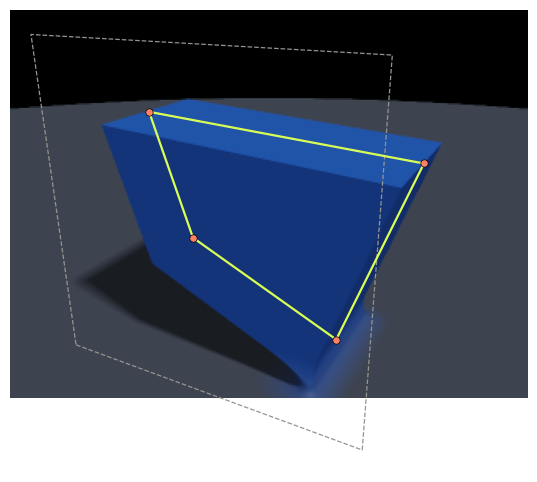

In [7]:
for v in quad.vertices:
    v.value = params[v.name]

quad_scene = Scene(
    quad_solid | Plane(-1.0, material=Material(color=[0.12, 0.14, 0.18], roughness=0.8)),
    camera=Camera(position=(3.6, 2.8, 5.0), target=(1.0, 0.6, 0.0), fov=0.45),
)
image = render_scene(quad_scene, settings)
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(image)
draw_plane(ax, quad.plane, quad_scene.camera, settings.resolution, extent=2.2)
draw_profile(ax, quad, quad_scene.camera, settings.resolution)
ax.axis("off");

Everything above is one parameter set: the constraint solver, the optimizer,
the SDF renderer, and the overlay all read and write the same `Vector2`
objects. Next steps for this workflow: sketch-on-face datums (deriving a
`SketchPlane` from an existing solid's geometry), more 2D entities (arcs,
fillets via smooth booleans), and interactive vertex dragging in the WebGPU
playground.